# 🤖 Instagram Performance Analysis — Travel Mex Tours
## Notebook 03: Machine Learning — Engagement Rate Prediction

**Author:** Maria Garcia Sehara  
**Project:** Social Media Analytics — Travel Mex Tours  
**Platform:** Instagram  

---

### Objective
Build and compare regression models to **predict Engagement Rate before publishing** a post.  
This gives the agency a data-driven tool to forecast performance and optimize content strategy.

### Models Compared
| Model | Why |
|-------|-----|
| Linear Regression | Simple baseline |
| Ridge Regression | Handles correlated features |
| Random Forest | Captures non-linear patterns |
| Gradient Boosting | Usually best performer |

### Evaluation Metrics
- **R²** — How much variance the model explains (higher = better, max = 1.0)
- **MAE** — Average prediction error in percentage points (lower = better)
- **RMSE** — Penalizes large errors more than MAE (lower = better)
- **CV R²** — Cross-validated R² (5-fold) — tells us if the model generalizes well


## 1. Setup & Data Load

In [1]:
import sys
import warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "../../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path

from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Style ──────────────────────────────────────────────────────────────────
BRAND_BLUE   = "#1877F2"
BRAND_PURPLE = "#833AB4"
BRAND_PINK   = "#E1306C"
PALETTE      = [BRAND_BLUE, BRAND_PURPLE, BRAND_PINK, "#FCAF45"]

sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({
    "figure.figsize":    (12, 5),
    "axes.titlesize":    14,
    "axes.labelsize":    12,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

FIGURES_PATH = Path("../../outputs/figures")
FIGURES_PATH.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE    = 0.20

print("✅ Setup complete")


✅ Setup complete


In [2]:
from load_data import load_instagram_csv
from preprocessing import preprocess_df

DATA_DIR  = Path("../../data/instagram/")
csv_files = sorted(DATA_DIR.glob("*.csv"), key=lambda f: f.stat().st_mtime, reverse=True)
if not csv_files:
    raise FileNotFoundError("No CSV found in data/instagram/")

df_raw   = load_instagram_csv(csv_files[0])
df, meta = preprocess_df(df_raw)

er_col   = meta["engagement_rate_col"]
date_col = meta.get("date_col")
type_col = meta.get("type_col")

print(f"✅ Data loaded  →  {len(df)} posts  |  target: {er_col}")


File successfully loaded: InstagramData.csv
   Shape: (125, 18)
   Detected content type: UNKNOWN
✅ Preprocessing completed!
   → Date column        : publish_time
   → ER calculated via  : REACH
   → Avg ER             : 15.36%
   → Date range         : 2025-05-01 → 2025-11-05
✅ Data loaded  →  125 posts  |  target: engagement_rate_pct


## 2. Feature Selection

In [3]:
# Numeric features — interaction metrics
numeric_keys = ["reach_col","impressions_col","views_col","likes_col",
                "comments_col","saves_col","shares_col","follows_col"]

numeric_feats = [
    meta[k] for k in numeric_keys
    if meta.get(k) and meta[k] in df.columns
]

# Categorical features — content type + time
cat_feats = []
if type_col and type_col in df.columns:
    cat_feats.append(type_col)
if "weekday" in df.columns:
    cat_feats.append("weekday")
if "hour" in df.columns:
    cat_feats.append("hour")
if "month" in df.columns:
    cat_feats.append("month")

print(f"Numeric features  ({len(numeric_feats)}) : {numeric_feats}")
print(f"Categorical features ({len(cat_feats)}) : {cat_feats}")
print(f"Target                              : {er_col}")


Numeric features  (7) : ['reach', 'views', 'likes', 'comments', 'saves', 'shares', 'follows']
Categorical features (4) : ['post_type', 'weekday', 'hour', 'month']
Target                              : engagement_rate_pct


In [4]:
# Build clean model dataset
all_feats = numeric_feats + cat_feats
model_df  = df[all_feats + [er_col]].dropna()

print(f"Total rows available : {len(df)}")
print(f"Rows after dropna    : {len(model_df)}")
print(f"Rows dropped         : {len(df) - len(model_df)}")

if len(model_df) < 30:
    raise ValueError(f"Only {len(model_df)} complete rows — need at least 30 for reliable ML.")

X = model_df[all_feats]
y = model_df[er_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"\nTrain set : {len(X_train)} rows")
print(f"Test set  : {len(X_test)} rows")


Total rows available : 125
Rows after dropna    : 121
Rows dropped         : 4

Train set : 96 rows
Test set  : 25 rows


## 3. Preprocessing Pipeline

In [5]:
# Build sklearn preprocessor
transformers = [("num", StandardScaler(), numeric_feats)]

if cat_feats:
    transformers.append(
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), cat_feats)
    )

preprocessor = ColumnTransformer(transformers, remainder="drop")

print("✅ Preprocessor ready")
print("   Numeric  → StandardScaler")
print("   Categorical → OneHotEncoder (drop first)")


✅ Preprocessor ready
   Numeric  → StandardScaler
   Categorical → OneHotEncoder (drop first)


## 4. Train & Evaluate All Models

In [6]:
model_zoo = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression":  Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=400, max_depth=10,
        min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300, max_depth=5,
        learning_rate=0.05, subsample=0.8,
        random_state=RANDOM_STATE
    ),
}

cv           = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results      = {}
pipelines    = {}

print(f"Training {len(model_zoo)} models...\n")

for name, model in model_zoo.items():
    pipe = Pipeline([("pre", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    r2   = round(r2_score(y_test, y_pred), 4)
    mae  = round(mean_absolute_error(y_test, y_pred), 4)
    rmse = round(float(np.sqrt(mean_squared_error(y_test, y_pred))), 4)

    cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="r2", n_jobs=-1)
    cv_mean   = round(float(cv_scores.mean()), 4)
    cv_std    = round(float(cv_scores.std()),  4)

    results[name]   = {"R2": r2, "MAE": mae, "RMSE": rmse,
                       "CV R2 Mean": cv_mean, "CV R2 Std": cv_std}
    pipelines[name] = pipe

    print(f"  {name}")
    print(f"     R²      : {r2}     CV R² : {cv_mean} ± {cv_std}")
    print(f"     MAE     : ±{mae}%")
    print(f"     RMSE    : {rmse}")
    print()

best_model = max(results, key=lambda x: results[x]["R2"])
print(f"⭐ Best model : {best_model}  (R² = {results[best_model]['R2']})")


Training 4 models...

  Linear Regression
     R²      : 0.7726     CV R² : 0.4363 ± 0.2181
     MAE     : ±3.1587%
     RMSE    : 3.952

  Ridge Regression
     R²      : 0.7427     CV R² : 0.492 ± 0.1745
     MAE     : ±3.3812%
     RMSE    : 4.2038

  Random Forest
     R²      : 0.7813     CV R² : 0.7165 ± 0.1507
     MAE     : ±3.0057%
     RMSE    : 3.8761

  Gradient Boosting
     R²      : 0.8834     CV R² : 0.8692 ± 0.0899
     MAE     : ±2.1751%
     RMSE    : 2.8305

⭐ Best model : Gradient Boosting  (R² = 0.8834)


## 5. Model Comparison

In [7]:
results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})
results_df = results_df.sort_values("R2", ascending=False)

display(results_df.style
    .highlight_max(subset=["R2", "CV R2 Mean"], color="#c6efce")
    .highlight_min(subset=["MAE", "RMSE"], color="#c6efce")
    .format(precision=4)
    .set_caption("Model Performance Comparison — Test Set + 5-Fold CV")
)


,Model,R2,MAE,RMSE,CV R2 Mean,CV R2 Std
3,Gradient Boosting,0.8834,2.1751,2.8305,0.8692,0.0899
2,Random Forest,0.7813,3.0057,3.8761,0.7165,0.1507
0,Linear Regression,0.7726,3.1587,3.9520,0.4363,0.2181
1,Ridge Regression,0.7427,3.3812,4.2038,0.4920,0.1745


In [8]:
fig = go.Figure()

colors = [BRAND_PINK if m == best_model else BRAND_BLUE for m in results_df["Model"]]

fig.add_trace(go.Bar(
    x=results_df["Model"],
    y=results_df["R2"],
    marker_color=colors,
    text=results_df["R2"].round(3),
    textposition="outside",
    name="R² Score"
))

fig.add_trace(go.Scatter(
    x=results_df["Model"],
    y=results_df["CV R2 Mean"],
    mode="markers+lines",
    marker=dict(size=10, color="orange"),
    name="CV R² Mean",
    line=dict(dash="dash")
))

fig.update_layout(
    title="Model Comparison — R² Score vs Cross-Validated R²",
    yaxis_title="R² Score",
    yaxis_range=[0, 1.1],
    legend=dict(orientation="h", yanchor="bottom", y=1.02)
)
fig.show()


## 6. Feature Importance — What Drives Engagement?

In [9]:
# Use best tree-based model for feature importance
fi_model_name = next(
    (m for m in ["Gradient Boosting", "Random Forest"] if m in pipelines),
    None
)

if fi_model_name:
    pipe = pipelines[fi_model_name]
    fitted_pre = pipe.named_steps["pre"]
    num_names  = numeric_feats.copy()

    try:
        ohe       = fitted_pre.named_transformers_["cat"]
        cat_names = ohe.get_feature_names_out(cat_feats).tolist()
    except Exception:
        cat_names = []

    all_names   = num_names + cat_names
    importances = pipe.named_steps["model"].feature_importances_

    if len(importances) == len(all_names):
        fi_df = (
            pd.DataFrame({"Feature": all_names, "Importance": importances})
            .sort_values("Importance", ascending=False)
            .round(4)
        )
        top_feature = fi_df.iloc[0]["Feature"]
        print(f"✅ Feature importance from: {fi_model_name}")
        print(f"   Top driver of engagement: {top_feature}")
        display(fi_df.head(10))
    else:
        print("⚠️  Feature name mismatch — showing raw importances")
        fi_df = None
else:
    fi_df = None
    print("⚠️  No tree-based model available for feature importance")


✅ Feature importance from: Gradient Boosting
   Top driver of engagement: reach


,Feature,Importance
0,reach,0.4853
2,likes,0.2830
1,views,0.0533
5,shares,0.0480
4,saves,0.0395
3,comments,0.0376
11,weekday_Thursday,0.0102
26,month_November,0.0067
12,weekday_Tuesday,0.0049
23,month_July,0.0049


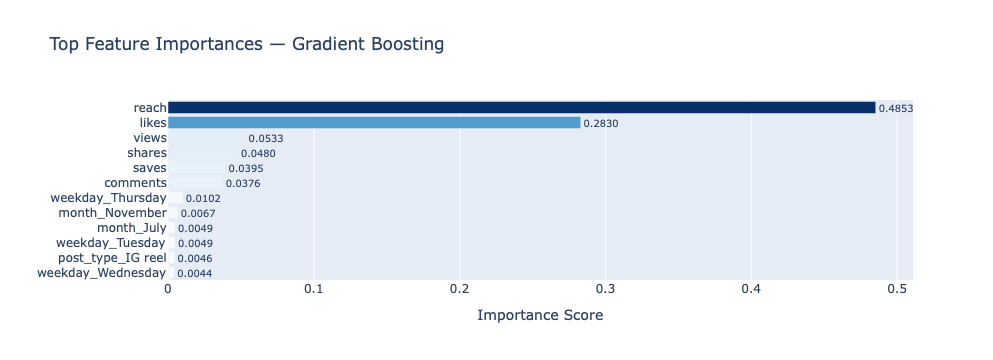

In [10]:
if fi_df is not None:
    top12 = fi_df.head(12)

    fig = px.bar(
        top12,
        x="Importance", y="Feature",
        orientation="h",
        color="Importance",
        color_continuous_scale="Blues",
        title=f"Top Feature Importances — {fi_model_name}",
        labels={"Importance": "Importance Score", "Feature": ""},
        text="Importance"
    )
    fig.update_traces(texttemplate="%{text:.4f}", textposition="outside")
    fig.update_layout(yaxis={"categoryorder": "total ascending"}, coloraxis_showscale=False)
    fig.show()


## 7. Actual vs Predicted — Best Model

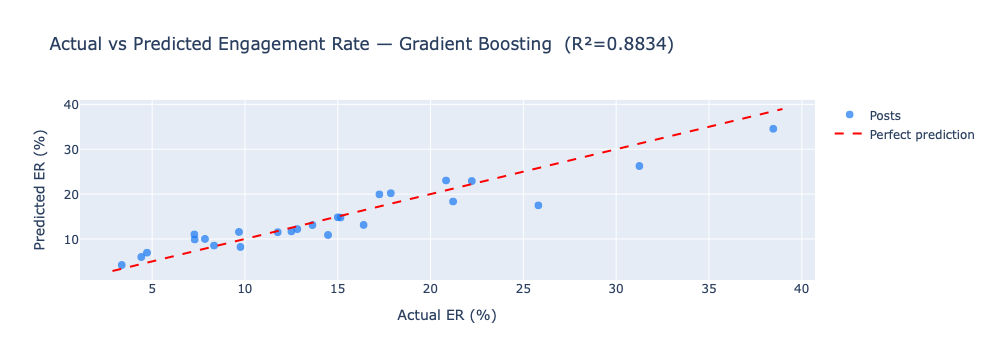

Residuals — Mean : 0.3241  |  Std : 2.8119
Max overestimate : +3.75%
Max underestimate: +8.32%


In [11]:
best_pipe  = pipelines[best_model]
y_pred_best = best_pipe.predict(X_test)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=y_test.values, y=y_pred_best,
    mode="markers",
    marker=dict(color=BRAND_BLUE, size=8, opacity=0.7),
    name="Posts"
))

lims = [min(y_test.min(), y_pred_best.min()) - 0.5,
        max(y_test.max(), y_pred_best.max()) + 0.5]

fig.add_trace(go.Scatter(
    x=lims, y=lims,
    mode="lines",
    line=dict(color="red", dash="dash", width=2),
    name="Perfect prediction"
))

fig.update_layout(
    title=f"Actual vs Predicted Engagement Rate — {best_model}  (R²={results[best_model]['R2']})",
    xaxis_title="Actual ER (%)",
    yaxis_title="Predicted ER (%)",
)
fig.show()

# Residuals
residuals = y_test.values - y_pred_best
print(f"Residuals — Mean : {residuals.mean():.4f}  |  Std : {residuals.std():.4f}")
print(f"Max overestimate : +{residuals.min()*-1:.2f}%")
print(f"Max underestimate: +{residuals.max():.2f}%")


## 8. 🚀 Predict Engagement Rate for a New Post

This is the practical tool — fill in the details of a post you're about to publish
and the model will predict its Engagement Rate.


In [12]:
# ── Fill in your post details here ────────────────────────────────────────
new_post = {
    # Numeric — estimated values before publishing
    meta.get("reach_col", "reach"):       5000,   # expected reach
    meta.get("views_col", "views"):       4000,   # expected views
    meta.get("likes_col", "likes"):        300,   # expected likes
    meta.get("comments_col", "comments"):  25,    # expected comments
    meta.get("saves_col", "saves"):        80,    # expected saves
    meta.get("shares_col", "shares"):      15,    # expected shares
    meta.get("follows_col", "follows"):    10,    # expected new follows
}

# Categorical — post details
if type_col:
    new_post[type_col] = "Reel"          # ← change to your content type

if "weekday" in cat_feats:
    new_post["weekday"] = "Tuesday"      # ← change to your planned posting day

if "hour" in cat_feats:
    new_post["hour"] = 9                 # ← change to your planned posting hour

if "month" in cat_feats:
    new_post["month"] = "July"           # ← change to the posting month

# ── Remove keys not in model features ─────────────────────────────────────
new_post = {k: v for k, v in new_post.items() if k in all_feats}

# ── Predict ────────────────────────────────────────────────────────────────
new_df         = pd.DataFrame([new_post])
predicted_er   = best_pipe.predict(new_df)[0]
avg_er         = df[er_col].mean()
benchmark      = 5.0   # correct benchmark for 1k-10k follower accounts

print("=" * 50)
print("  ENGAGEMENT RATE PREDICTION")
print("=" * 50)
print(f"  Model used        : {best_model}")
print(f"  Predicted ER      : {predicted_er:.2f}%")
print(f"  Your account avg  : {avg_er:.2f}%")
print(f"  Benchmark (1k-10k): {benchmark}%  — Travel Mex has 2,608 followers")
print()
if predicted_er >= avg_er * 1.1:
    print("  ✅ Prediction: ABOVE your average — great post!")
elif predicted_er >= benchmark:
    print("  ✅ Prediction: Above industry benchmark")
else:
    print("  ⚠️  Prediction: Below average — consider adjusting the content")
print("=" * 50)


  ENGAGEMENT RATE PREDICTION
  Model used        : Gradient Boosting
  Predicted ER      : 13.52%
  Your account avg  : 15.36%
  Benchmark (1k-10k): 5.0%  — Travel Mex has 2,608 followers

  ✅ Prediction: Above industry benchmark


## 9. Executive Summary

In [13]:
bm = results[best_model]

print("=" * 60)
print("  MACHINE LEARNING SUMMARY — TRAVEL MEX TOURS")
print("=" * 60)
print(f"\n🏆 Best Model        : {best_model}")
print(f"   R² Score          : {bm['R2']}  ({bm['R2']*100:.0f}% of variance explained)")
print(f"   MAE               : ±{bm['MAE']}%  (avg prediction error)")
print(f"   RMSE              : {bm['RMSE']}")
print(f"   CV R² (5-fold)    : {bm['CV R2 Mean']} ± {bm['CV R2 Std']}  (generalization)")

if fi_df is not None:
    print(f"\n🔑 Top 3 Engagement Drivers:")
    for i, row in fi_df.head(3).iterrows():
        print(f"   {i+1}. {row['Feature']:25s}: {row['Importance']:.4f}")

print(f"\n🎯 Strategic Recommendations:")
print(f"   1. Optimize {fi_df.iloc[0]['Feature'] if fi_df is not None else 'top features'} — biggest lever for engagement")
print(f"   2. Use the prediction tool (Section 8) before every post")
print(f"   3. Re-train this model monthly as new data comes in")
print(f"   4. Target posts predicted above {df[er_col].mean():.1f}% (your avg)")
print("=" * 60)
print("\n✅ Analysis complete — Ready for Streamlit Dashboard!")


  MACHINE LEARNING SUMMARY — TRAVEL MEX TOURS

🏆 Best Model        : Gradient Boosting
   R² Score          : 0.8834  (88% of variance explained)
   MAE               : ±2.1751%  (avg prediction error)
   RMSE              : 2.8305
   CV R² (5-fold)    : 0.8692 ± 0.0899  (generalization)

🔑 Top 3 Engagement Drivers:
   1. reach                    : 0.4853
   3. likes                    : 0.2830
   2. views                    : 0.0533

🎯 Strategic Recommendations:
   1. Optimize reach — biggest lever for engagement
   2. Use the prediction tool (Section 8) before every post
   3. Re-train this model monthly as new data comes in
   4. Target posts predicted above 15.4% (your avg)

✅ Analysis complete — Ready for Streamlit Dashboard!
